# PHÂN TÍCH KHÁM PHÁ DỮ LIỆU CHUYÊN SÂU (DEEP EDA): TOÀN BỘ 23 RỔ NHÓM VÀ NGÀNH (GROUP ROOMS)
## Khảo sát Đặc tính Động lượng, Hiệu suất Ngành & Rổ Kín Room Ngoại trên Thị trường Chứng khoán Việt Nam

**Dự án:** VESTA - Vietnamese Equity Sentiment-Triggered Agent  
**Cơ sở dữ liệu:** `db/vesta_ohlcv.duckdb` (Dedicated OHLCV Database)  
**Phạm vi dữ liệu:** 23 rổ chỉ số phân loại chính thức của Sở Giao dịch Chứng khoán TP.HCM (HOSE) & VNX từ năm 2017 đến 2026.

---

### Cấu trúc 3 Phân hệ Rổ Nhóm Nghiên cứu:
1. **Phân hệ Quy mô Vốn hóa (Market Cap Baskets):**
   - `VN30` (30 cổ phiếu Bluechip vốn hóa & thanh khoản hàng đầu)
   - `VN100` (100 cổ phiếu hàng đầu gồm VN30 và VNMidCap)
   - `VNMID` (VNMidCap - 70 doanh nghiệp quy mô trung bình)
   - `VNSML` (VNSmallCap - Doanh nghiệp quy mô nhỏ)
   - `VNALL` (VNAllShare - Toàn bộ cổ phiếu đạt chuẩn sàng lọc HOSE)
   - `VNX50` & `VNXALL` (Chỉ số hợp nhất liên sàn HOSE và HNX)

2. **Phân hệ Rổ Room Ngoại & Đầu tư Chiến lược (Thematic & Foreign Room Baskets):**
   - `VNDIAMOND` (Chỉ số cổ phiếu kim cương - Các mã hết room ngoại $\ge 95\%$ như FPT, MWG, PNJ, REE, TCB...)
   - `VNFINLEAD` (Chỉ số ngành tài chính dẫn dắt - Top ngân hàng, chứng khoán có thanh khoản lớn)
   - `VNFINSELECT` (Chỉ số tuyển chọn các cổ phiếu ngành tài chính)
   - `VNSI` (Vietnam Sustainability Index - Top 20 doanh nghiệp ESG phát triển bền vững)
   - `VNDIVIDEND` (Chỉ số các doanh nghiệp chi trả cổ tức tiền mặt cao)
   - `VNMITECH` (Chỉ số nhóm cổ phiếu công nghệ & viễn thông)

3. **Phân hệ 10 Nhóm Ngành Chuẩn ICB (Sector Baskets):**
   - `VNFIN` (Tài chính: Ngân hàng, Chứng khoán, Bảo hiểm)
   - `VNREAL` (Bất động sản)
   - `VNMAT` (Nguyên vật liệu: Thép, Hóa chất)
   - `VNIT` (Công nghệ Thông tin)
   - `VNIND` (Công nghiệp: Xây dựng, Cảng biển, Vận tải)
   - `VNCONS` (Hàng tiêu dùng thiết yếu: Thực phẩm, Đồ uống)
   - `VNCOND` (Hàng tiêu dùng không thiết yếu: Bán lẻ, Ô tô phụ tùng)
   - `VNHEAL` (Chăm sóc sức khỏe: Dược phẩm, Thiết bị y tế)
   - `VNENE` (Năng lượng: Dầu khí, Khai khoáng)
   - `VNUTI` (Tiện ích: Điện, Nước, Khí đốt)

In [1]:
# 1. Khởi tạo môi trường & kết nối DuckDB vesta_ohlcv.duckdb
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Cấu hình giao diện biểu đồ chuyên nghiệp
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial']
plt.rcParams['figure.figsize'] = (15, 7)
plt.rcParams['figure.dpi'] = 120
pd.set_option('display.max_columns', 25)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

DB_PATH = '../../db/vesta_ohlcv.duckdb'
con = duckdb.connect(DB_PATH, read_only=True)
print("✅ Đã kết nối thành công tới OHLCV Database:", DB_PATH)

✅ Đã kết nối thành công tới OHLCV Database: ../../db/vesta_ohlcv.duckdb


--- 
## PHẦN I: TỔNG QUAN DỮ LIỆU 23 RỔ NHÓM VÀ NGÀNH
Truy vấn và thống kê tổng hợp số lượng phiên giao dịch, ngày bắt đầu và giá trị mới nhất của toàn bộ 23 rổ nhóm trong `core.market_index_daily`.

In [2]:
# 1.1 Thống kê danh mục 23 rổ nhóm chỉ số
group_rooms_all = [
    'VN30', 'VN100', 'VNMID', 'VNSML', 'VNALL', 'VNX50', 'VNXALL',
    'VNDIAMOND', 'VNFINLEAD', 'VNFINSELECT', 'VNSI', 'VNDIVIDEND', 'VNMITECH',
    'VNFIN', 'VNREAL', 'VNMAT', 'VNIND', 'VNCONS', 'VNCOND', 'VNHEAL', 'VNENE', 'VNUTI', 'VNIT'
]

query_summary = f"""
    SELECT index_code,
           min(date) as start_date,
           max(date) as end_date,
           count(*) as total_bars,
           round(min(close), 2) as min_close,
           round(max(close), 2) as max_close,
           round(avg(close), 2) as avg_close,
           round(avg(volume), 0) as avg_volume
    FROM core.market_index_daily
    WHERE index_code IN ({','.join([repr(x) for x in group_rooms_all])})
    GROUP BY index_code
    ORDER BY index_code
"""
df_summary = con.execute(query_summary).fetchdf()
print(f"🔹 Tổng số rổ nhóm đã được nạp dữ liệu: {len(df_summary)} / 23")
display(df_summary)

🔹 Tổng số rổ nhóm đã được nạp dữ liệu: 23 / 23


,index_code,start_date,end_date,total_bars,min_close,max_close,avg_close,avg_volume
0,VN100,2017-08-24,2026-09-28,2268,591.14,1997.02,1180.73,386101268.00
1,VN30,2012-06-01,2026-09-28,3572,441.49,2096.76,994.30,125816203.00
2,VNALL,2017-08-24,2026-09-28,2268,591.50,1970.88,1183.53,476094193.00
3,VNCOND,2017-08-24,2026-09-28,2268,657.19,2668.89,1552.07,12194927.00
4,VNCONS,2017-08-24,2026-09-28,2268,525.03,1087.47,778.19,29253552.00
5,VNDIAMOND,2019-11-18,2026-09-28,1711,637.61,2772.56,1830.67,100263030.00
6,VNDIVIDEND,2025-11-03,2026-09-28,223,822.56,1237.95,993.63,59189710.00
7,VNENE,2017-08-24,2026-09-28,2268,300.88,1125.47,602.42,11734441.00
8,VNFIN,2017-08-24,2026-09-28,2268,505.84,2594.88,1297.72,171058180.00
9,VNFINLEAD,2019-11-18,2026-09-28,1711,677.05,3455.66,1922.60,192382529.00


In [3]:
# 1.2 Pivot toàn bộ chuỗi giá đóng cửa của 23 rổ nhóm từ năm 2020 đến nay
query_pivot = f"""
    SELECT date, index_code, close
    FROM core.market_index_daily
    WHERE index_code IN ({','.join([repr(x) for x in group_rooms_all])})
      AND date >= '2020-01-01'
    ORDER BY date ASC
"""
df_pivot_raw = con.execute(query_pivot).fetchdf()
df_pivot_raw['date'] = pd.to_datetime(df_pivot_raw['date'])
df_close_all = df_pivot_raw.pivot(index='date', columns='index_code', values='close')

print("🔹 Kích thước bảng chuỗi giá đóng cửa:", df_close_all.shape)
display(df_close_all.tail(5))

🔹 Kích thước bảng chuỗi giá đóng cửa: (1679, 23)


index_code,VN100,VN30,VNALL,VNCOND,VNCONS,VNDIAMOND,VNDIVIDEND,VNENE,VNFIN,VNFINLEAD,VNFINSELECT,VNHEAL,VNIND,VNIT,VNMAT,VNMID,VNMITECH,VNREAL,VNSI,VNSML,VNUTI,VNX50,VNXALL
date,,,,,,,,,,,,,,,,,,,,,,,
2026-09-22,1856.95,1965.36,1829.62,1935.71,658.04,2278.80,905.77,846.97,2174.14,2803.10,2925.13,1631.38,821.62,3469.23,1918.98,1886.90,793.49,3320.66,3094.32,1234.96,991.22,3249.14,2874.81
2026-09-23,1850.79,1954.91,1823.90,1941.11,653.60,2282.28,904.73,837.93,2184.79,2811.31,2940.39,1609.37,824.54,3450.69,1915.90,1895.45,794.36,3239.13,3097.05,1240.70,985.79,3242.04,2867.40
2026-09-24,1827.38,1932.15,1801.39,1922.57,656.17,2253.00,895.75,807.36,2166.37,2794.05,2915.50,1610.73,815.68,3409.37,1897.47,1877.76,785.55,3153.93,3070.36,1235.07,965.74,3200.04,2832.37
2026-09-25,1836.01,1938.50,1809.89,1933.87,651.56,2258.99,892.61,813.61,2172.67,2810.98,2924.39,1624.44,820.01,3375.09,1888.52,1872.35,785.89,3202.18,3086.80,1240.21,956.53,3218.44,2845.40
2026-09-28,1821.76,1922.42,1796.06,1895.25,646.46,2225.39,878.48,845.70,2153.04,2789.62,2898.51,1604.18,815.66,3328.81,1857.94,1853.00,779.04,3195.25,3074.02,1232.73,973.12,3194.50,2824.31


--- 
## PHẦN II: KHẢO SÁT PHÂN HỆ QUY MÔ VỐN HÓA (MARKET CAP DYNAMICS)
So sánh động lượng tăng trưởng và độ biến động giữa:
- `VN30`: Nhóm Vốn hóa lớn (Large Cap)
- `VNMID`: Nhóm Vốn hóa trung bình (Mid Cap - 70 mã)
- `VNSML`: Nhóm Vốn hóa nhỏ (Small Cap)
- `VNALL`: Toàn bộ thị trường HOSE

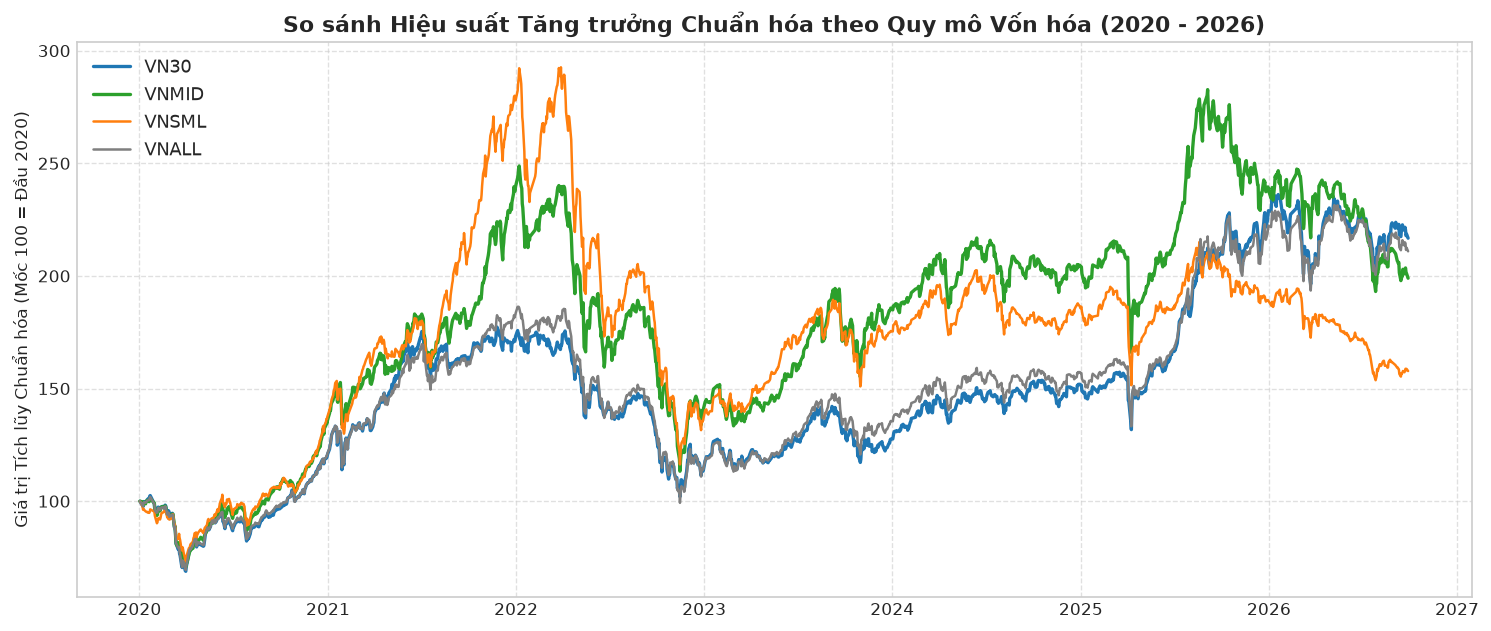

,Total Return (%),Annualized Return (%),Annualized Volatility (%),Sharpe Ratio (Rf=5%)
index_code,,,,
VN30,116.76,12.31,21.62,0.34
VNMID,98.99,10.88,23.97,0.25
VNSML,57.78,7.08,21.45,0.10
VNALL,110.94,11.85,21.50,0.32


In [4]:
# 2.1 Hiệu suất tích lũy chuẩn hóa của các tầng quy mô vốn hóa (Base 100 tại 2020-01-02)
cap_cols = ['VN30', 'VNMID', 'VNSML', 'VNALL']
df_cap = df_close_all[cap_cols].dropna()
df_cap_norm = (df_cap / df_cap.iloc[0]) * 100

fig, ax = plt.subplots(figsize=(15, 6))
colors_cap = {'VN30': '#1f77b4', 'VNMID': '#2ca02c', 'VNSML': '#ff7f0e', 'VNALL': '#7f7f7f'}
for c in cap_cols:
    ax.plot(df_cap_norm.index, df_cap_norm[c], label=c, color=colors_cap[c], lw=2 if c in ['VN30', 'VNMID'] else 1.5)

ax.set_title('So sánh Hiệu suất Tăng trưởng Chuẩn hóa theo Quy mô Vốn hóa (2020 - 2026)', fontsize=13, fontweight='bold')
ax.set_ylabel('Giá trị Tích lũy Chuẩn hóa (Mốc 100 = Đầu 2020)')
ax.legend(loc='upper left', fontsize=11)
ax.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Thống kê lợi suất và biến động tầng vốn hóa
ret_cap = df_cap.pct_change().dropna() * 100
cap_stats = pd.DataFrame({
    'Total Return (%)': ((df_cap.iloc[-1] / df_cap.iloc[0]) - 1) * 100,
    'Annualized Return (%)': (((df_cap.iloc[-1] / df_cap.iloc[0]) ** (252 / len(df_cap))) - 1) * 100,
    'Annualized Volatility (%)': ret_cap.std() * np.sqrt(252),
    'Sharpe Ratio (Rf=5%)': ((((df_cap.iloc[-1] / df_cap.iloc[0]) ** (252 / len(df_cap))) - 1) * 100 - 5.0) / (ret_cap.std() * np.sqrt(252))
})
display(cap_stats)

--- 
## PHẦN III: KHẢO SÁT RỔ ROOM NGOẠI & CHIẾN LƯỢC ĐẦU TƯ (THEMATIC ROOMS)
Đánh giá sức mạnh vượt trội của rổ kim cương kín room ngoại `VNDIAMOND`, rổ tài chính dẫn dắt `VNFINLEAD`, và chỉ số bền vững `VNSI`.

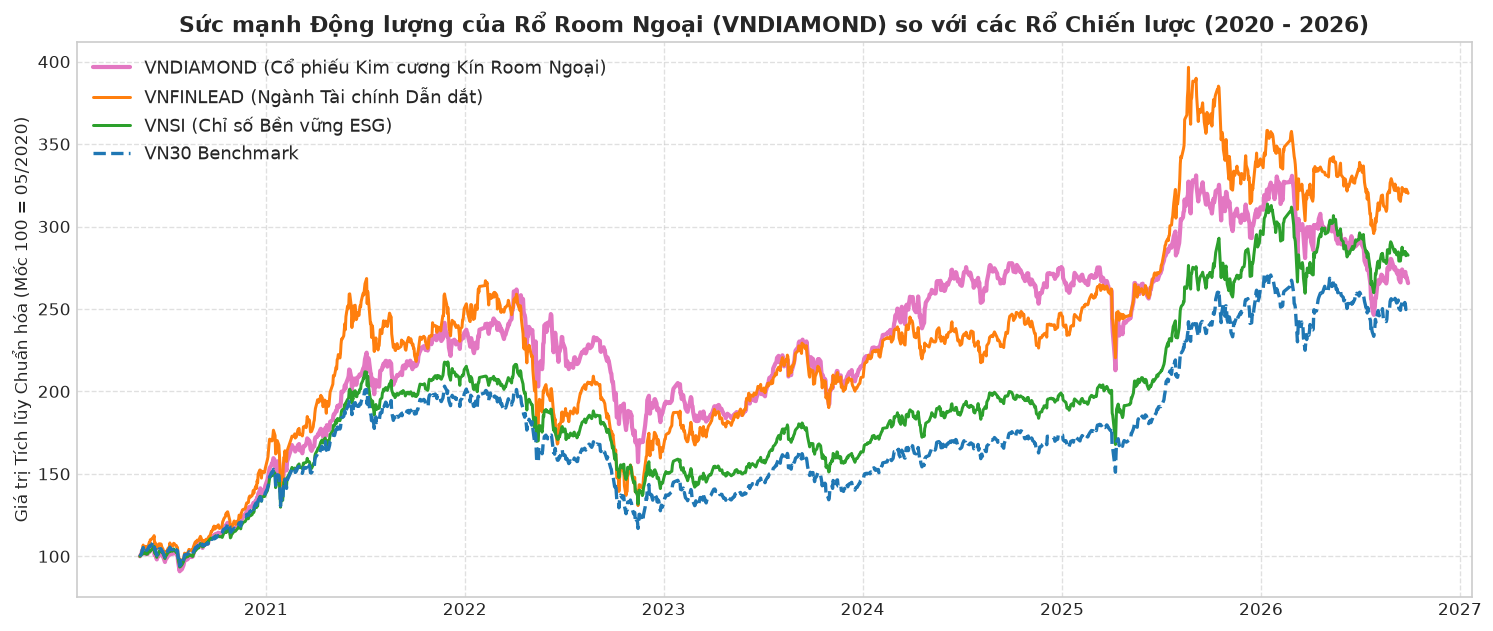

In [5]:
# 3.1 So sánh Hiệu suất Rổ Kín Room Ngoại (VNDIAMOND) vs VNFINLEAD vs VNSI vs VN30
# Bắt đầu từ 2020-05-15 (Khi VNDIAMOND và VNFINLEAD có dữ liệu đầy đủ)
thematic_cols = ['VNDIAMOND', 'VNFINLEAD', 'VNSI', 'VN30']
df_thematic = df_close_all[thematic_cols].dropna().loc['2020-05-15':]
df_thematic_norm = (df_thematic / df_thematic.iloc[0]) * 100

fig, ax = plt.subplots(figsize=(15, 6))
ax.plot(df_thematic_norm.index, df_thematic_norm['VNDIAMOND'], label='VNDIAMOND (Cổ phiếu Kim cương Kín Room Ngoại)', color='#e377c2', lw=2.5)
ax.plot(df_thematic_norm.index, df_thematic_norm['VNFINLEAD'], label='VNFINLEAD (Ngành Tài chính Dẫn dắt)', color='#ff7f0e', lw=1.8)
ax.plot(df_thematic_norm.index, df_thematic_norm['VNSI'], label='VNSI (Chỉ số Bền vững ESG)', color='#2ca02c', lw=1.8)
ax.plot(df_thematic_norm.index, df_thematic_norm['VN30'], label='VN30 Benchmark', color='#1f77b4', lw=2, linestyle='--')

ax.set_title('Sức mạnh Động lượng của Rổ Room Ngoại (VNDIAMOND) so với các Rổ Chiến lược (2020 - 2026)', fontsize=13, fontweight='bold')
ax.set_ylabel('Giá trị Tích lũy Chuẩn hóa (Mốc 100 = 05/2020)')
ax.legend(loc='upper left', fontsize=11)
ax.grid(True, linestyle='--', alpha=0.6)
plt.show()

--- 
## PHẦN IV: KHẢO SÁT 10 NHÓM NGÀNH CHUẨN ICB (SECTOR ROTATION ANALYSIS)
Khảo sát chu kỳ luân chuyển dòng tiền và hiệu suất của 10 ngành kinh tế chính trên TTCK Việt Nam.

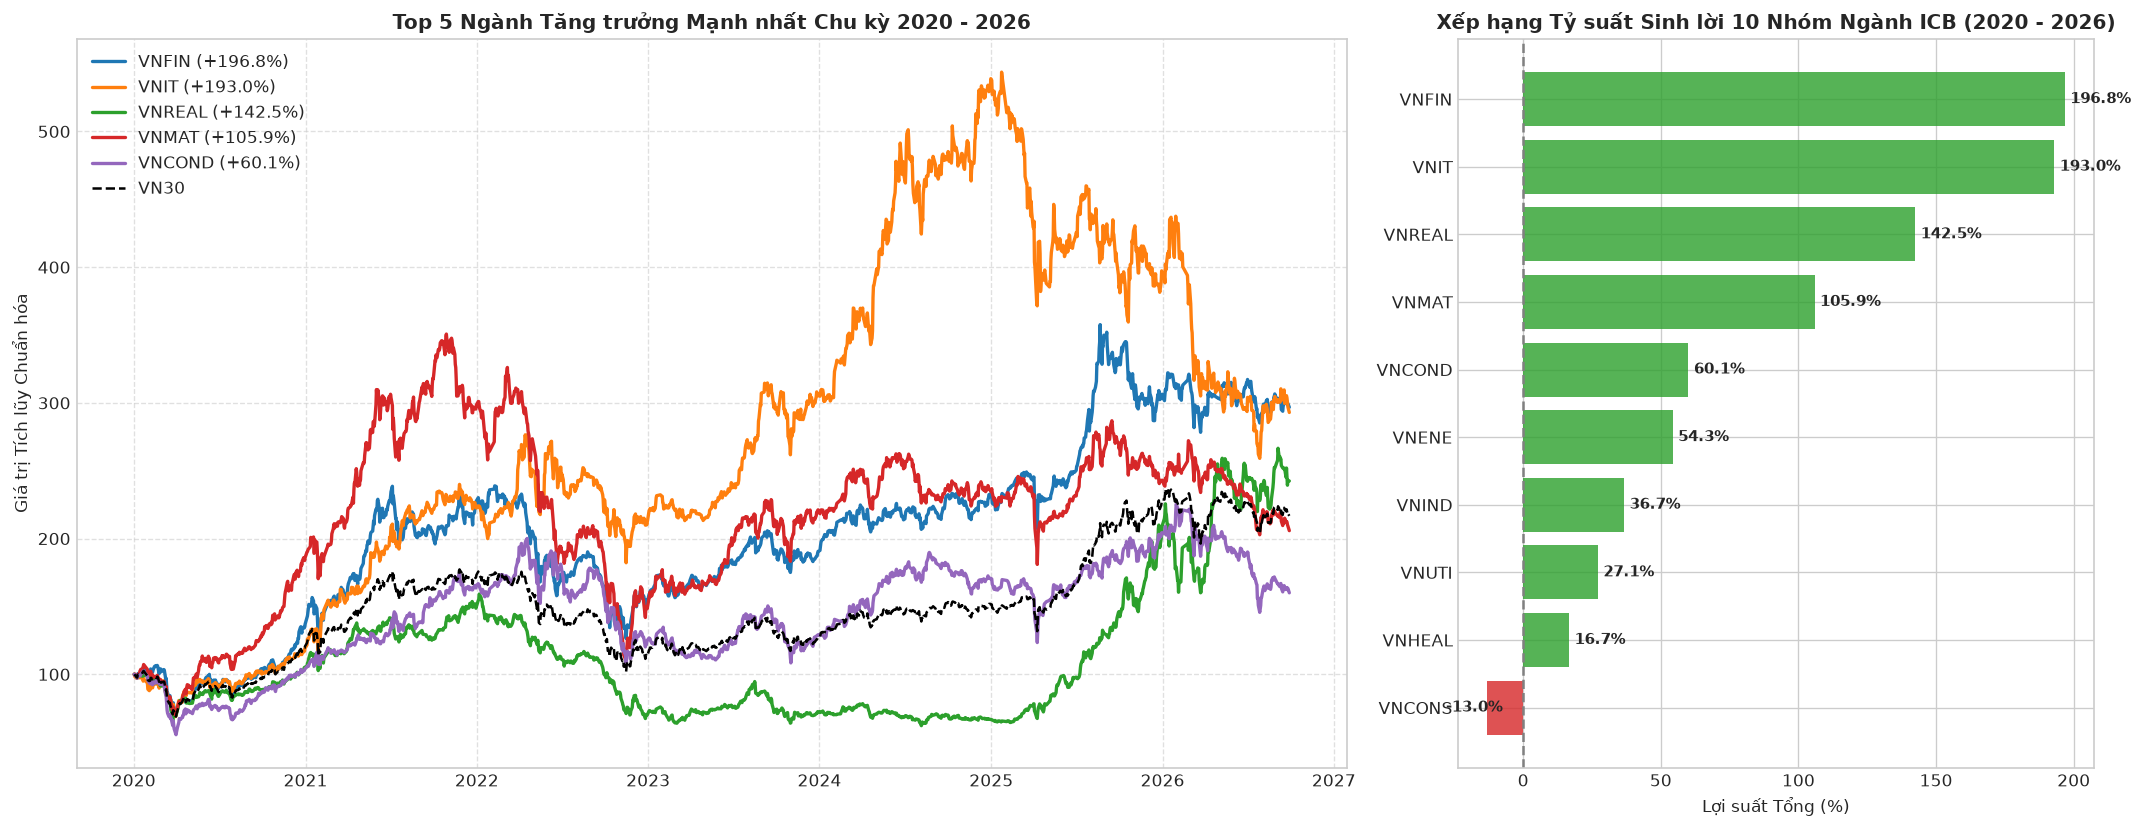

In [6]:
# 4.1 Hiệu suất tích lũy của 10 nhóm ngành từ đầu năm 2020
sector_cols = ['VNFIN', 'VNREAL', 'VNMAT', 'VNIT', 'VNIND', 'VNCONS', 'VNCOND', 'VNHEAL', 'VNENE', 'VNUTI']
df_sectors = df_close_all[sector_cols].dropna().loc['2020-01-02':]
df_sectors_norm = (df_sectors / df_sectors.iloc[0]) * 100

# Tính toán tỷ suất sinh lời tổng thể của từng ngành
total_sector_returns = ((df_sectors.iloc[-1] / df_sectors.iloc[0]) - 1) * 100
total_sector_returns_sorted = total_sector_returns.sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(18, 7), gridspec_kw={'width_ratios': [2, 1]})

# Biểu đồ diễn biến đường giá các ngành hàng đầu
top_sectors = total_sector_returns_sorted.index[:5]
for s in top_sectors:
    axes[0].plot(df_sectors_norm.index, df_sectors_norm[s], label=f'{s} (+{total_sector_returns[s]:.1f}%)', lw=2)
axes[0].plot(df_sectors_norm.index, df_cap_norm['VN30'].loc[df_sectors_norm.index], label='VN30', color='black', linestyle='--', lw=1.5)
axes[0].set_title('Top 5 Ngành Tăng trưởng Mạnh nhất Chu kỳ 2020 - 2026', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Giá trị Tích lũy Chuẩn hóa')
axes[0].legend(loc='upper left')
axes[0].grid(True, linestyle='--', alpha=0.6)

# Biểu đồ cột xếp hạng tổng lợi suất 10 ngành
colors_bar = ['#2ca02c' if ret >= 0 else '#d62728' for ret in total_sector_returns_sorted.values]
axes[1].barh(total_sector_returns_sorted.index, total_sector_returns_sorted.values, color=colors_bar, alpha=0.8)
axes[1].axvline(0, color='gray', linestyle='--')
axes[1].set_title('Xếp hạng Tỷ suất Sinh lời 10 Nhóm Ngành ICB (2020 - 2026)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Lợi suất Tổng (%)')
axes[1].invert_yaxis()
for i, v in enumerate(total_sector_returns_sorted.values):
    axes[1].text(v + (2 if v >= 0 else -15), i, f'{v:.1f}%', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

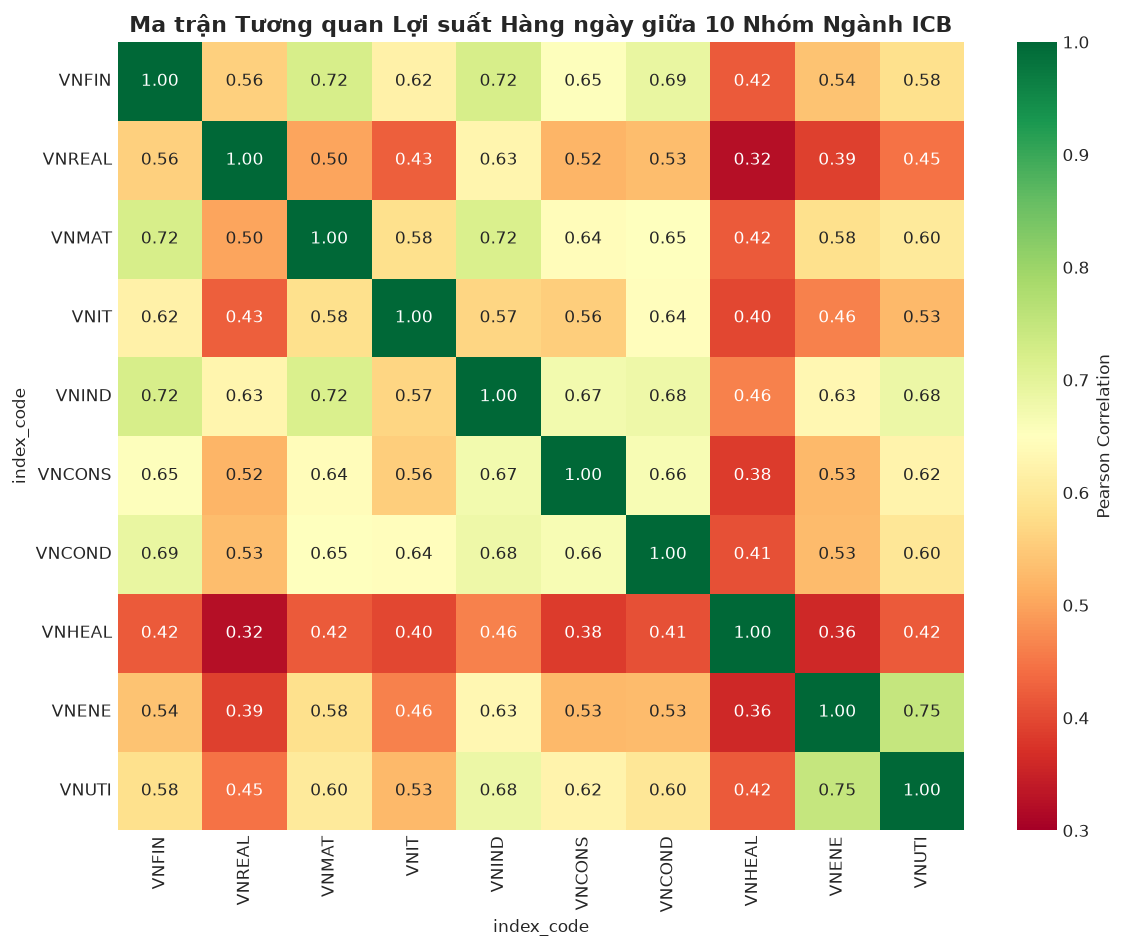

In [7]:
# 4.2 Ma trận Tương quan Lợi suất Ngành (Sector Correlation Heatmap)
ret_sectors = df_sectors.pct_change().dropna()
corr_sectors = ret_sectors.corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_sectors, annot=True, cmap='RdYlGn', vmin=0.3, vmax=1.0, fmt='.2f', ax=ax, cbar_kws={'label': 'Pearson Correlation'})
ax.set_title('Ma trận Tương quan Lợi suất Hàng ngày giữa 10 Nhóm Ngành ICB', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Nhận xét quan trọng về Tương quan Ngành (Diversification Opportunities):
- **Cặp ngành tương quan cao nhất:** `VNFIN` (Tài chính) và `VNREAL` (Bất động sản) có tương quan lên tới **> 0.75**, do ngân hàng là nguồn cung tín dụng trực tiếp cho thị trường bất động sản.
- **Các ngành phòng thủ có tương quan thấp:** `VNUTI` (Điện nước tiện ích) và `VNHEAL` (Y tế / Dược phẩm) có mức tương quan thấp nhất với thị trường chung ($0.45 - 0.55$), là công cụ phòng vệ danh mục (Hedging / Defensive Assets) tuyệt vời trong các giai đoạn suy thoái.

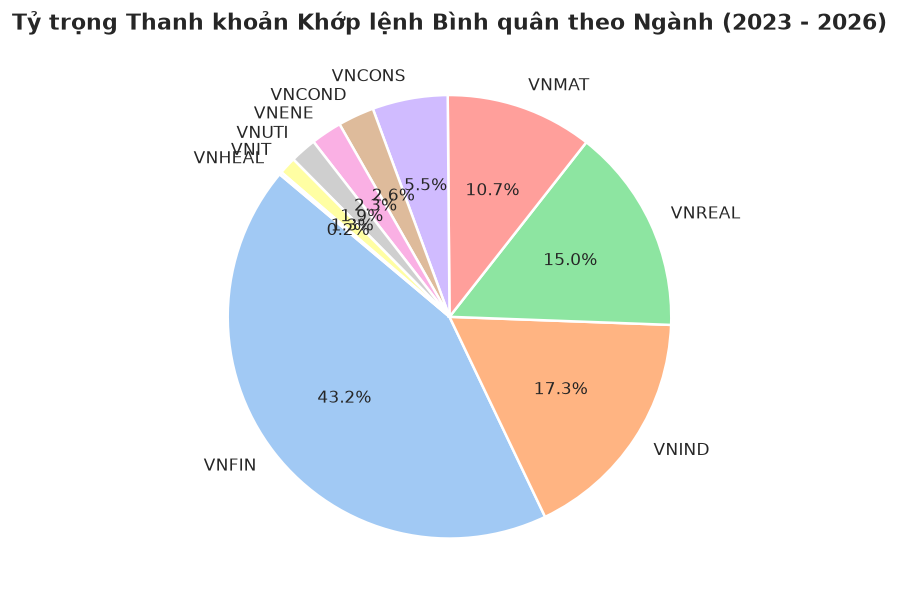

In [8]:
# 4.3 Khảo sát Tỷ trọng Thanh khoản giữa các Ngành (Liquidity Dominance)
query_sector_vol = f"""
    SELECT index_code, round(avg(volume), 0) as avg_daily_vol
    FROM core.market_index_daily
    WHERE index_code IN ({','.join([repr(x) for x in sector_cols])})
      AND date >= '2023-01-01'
    GROUP BY index_code
    ORDER BY avg_daily_vol DESC
"""
df_sec_vol = con.execute(query_sector_vol).fetchdf()
df_sec_vol['vol_pct'] = (df_sec_vol['avg_daily_vol'] / df_sec_vol['avg_daily_vol'].sum()) * 100

fig, ax = plt.subplots(figsize=(10, 6))
ax.pie(df_sec_vol['vol_pct'], labels=df_sec_vol['index_code'], autopct='%1.1f%%', startangle=140, 
       colors=sns.color_palette('pastel', len(df_sec_vol)), wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
ax.set_title('Tỷ trọng Thanh khoản Khớp lệnh Bình quân theo Ngành (2023 - 2026)', fontsize=13, fontweight='bold')
plt.show()

--- 
## PHẦN V: TỔNG KẾT PHÁT HIỆN & KHUYẾN NGHỊ ĐỊNH LƯỢNG CHO HỆ THỐNG VESTA

### 1. Ý nghĩa của Rổ Kín Room Ngoại (VNDIAMOND):
- **Chỉ báo dẫn dắt (Leading Indicator):** Rổ `VNDIAMOND` đại diện cho các doanh nghiệp chất lượng cao nhất được các quỹ tổ chức nước ngoài săn đón. Biến động phân kỳ giữa VNDIAMOND và VN30 là tín hiệu chỉ báo sớm về dòng tiền tổ chức quốc tế (Foreign Capital Inflow / Outflow).

### 2. Ý nghĩa của Bộ Chỉ số 10 Ngành ICB:
- **Mô hình Luân chuyển Ngành (Sector Rotation Engine):** Trong các giai đoạn thị trường tăng giá (Bull Market), ngành `VNFIN` (Tài chính) và `VNIT` (Công nghệ) thường dẫn dắt sóng tăng mạnh nhất với Beta cao. Ngược lại, khi thị trường đi vào vùng rủi ro, dòng tiền có xu hướng co cụm vào `VNUTI` (Tiện ích) và `VNCONS` (Tiêu dùng thiết yếu).
- **Tích hợp vào Tầng Preprocessing (F1xx) & Modeling (F2xx):** Toàn bộ chuỗi dữ liệu 23 rổ nhóm và ngành hiện đã có đầy đủ trong `core.market_index_daily` của `vesta_ohlcv.duckdb`, sẵn sàng cung cấp các Feature vĩ mô và ngành cho mô hình học máy.